In [1]:
import numpy as np
import seaborn as sns
import math
import pickle
from timeit import default_timer as timer
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [2]:
data = datasets.load_breast_cancer()
X,y = data.data, data.target

In [3]:
X_t,X_test, y_t,y_test = train_test_split(X,y,test_size=0.2, random_state=23)

In [2]:
from randomForest import RandomForest

In [5]:
clf = RandomForest(n_trees=5,max_depth=10,dr_max=3,k=3,n_features=5)

In [6]:
clf.fit(X_t,y_t)

In [7]:
pred = clf.predict(X_test)

In [8]:
acc = clf.accuracy(pred,y_test)

In [9]:
print(acc)

0.9649122807017544


In [10]:
# Indexing out the data-points to be unlearned
x_rem,y_rem = X_t[:45], y_t[:45]

In [11]:
for i in range(45):
    clf.unlearn(x_rem[i],y_rem[i])

In [12]:
pred = clf.predict(X_test)
print(clf.accuracy(pred,y_test))

0.9649122807017544


In [13]:
print(confusion_matrix(y_test,pred))

[[37  2]
 [ 2 73]]


In [3]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

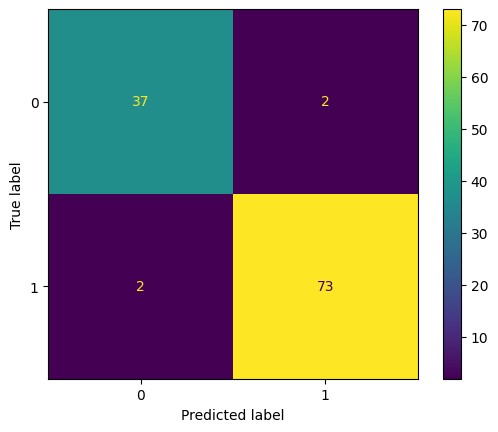

In [15]:
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## Using SemEval 2018

In [4]:
with open('Data_train.pkl', 'rb') as f:
    train_data = pickle.load(f)

In [5]:
with open('Data_test.pkl', 'rb') as f:
    test_data = pickle.load(f)

In [6]:
with open('Data_dev.pkl', 'rb') as f:
    dev_data = pickle.load(f)

In [7]:
train_data

,BERT_Embedding,Binary Intensity
0,"[0.631012, 0.029624153, -0.0679106, -0.2182588...",1
1,"[0.2812575, 0.068546996, 0.2663357, -0.3572532...",1
2,"[0.34230626, 0.14864753, 0.075299904, -0.17365...",0
3,"[0.03704805, -0.32440692, 0.57933986, -0.17894...",0
4,"[0.19555026, 0.2703592, 0.39218858, -0.2639042...",0
...,...,...
7097,"[0.19181098, -0.011471932, 0.1792148, 0.030552...",1
7098,"[0.34865552, -0.29214165, 0.4551607, 0.1538953...",1
7099,"[0.5002236, -0.07981106, 0.13967259, 0.1843870...",1
7100,"[-0.017593732, 0.31776246, 0.12661323, -0.0079...",0


In [8]:
X_train = np.stack(train_data["BERT_Embedding"].to_numpy())

In [9]:
X_train.shape

(7102, 768)

In [10]:
y_train = train_data["Binary Intensity"].to_numpy()

In [11]:
y_train.shape

(7102,)

In [12]:
dev_data

,BERT_Embedding,Binary Intensity
0,"[-0.14867646, 0.41100022, 0.32911435, -0.25633...",0
1,"[-0.15210624, -0.46638465, 0.46334597, -0.0100...",1
2,"[0.182779, 0.1772878, 0.083135486, -0.05063649...",0
3,"[0.28336036, -0.17219567, 0.38972953, -0.08701...",1
4,"[0.19772193, -0.11237176, 0.94873893, 0.088894...",0
...,...,...
1459,"[0.32470468, 0.040295396, 0.98798686, -0.01516...",1
1460,"[0.02895116, 0.15055703, 0.83012486, -0.145735...",0
1461,"[-0.02299733, -0.06982645, 0.653659, 0.0364502...",0
1462,"[0.15542084, -0.027912796, 0.46936354, -0.0579...",1


In [13]:
X_dev = np.stack(dev_data["BERT_Embedding"].to_numpy())

In [14]:
y_dev = dev_data["Binary Intensity"].to_numpy()

In [15]:
X_dev.shape, y_dev.shape

((1464, 768), (1464,))

### Making new Random Forest instance

In [16]:
model1 = RandomForest(n_trees=100,max_depth=17,dr_max=5,k=3,n_features=int(math.sqrt(X_train.shape[1])))

In [17]:
start = timer()
model1.fit(X_train,y_train)
end = timer()

In [18]:
training_time = end-start

In [19]:
training_time

3445.678048318

In [20]:
pred = model1.predict(X_dev)

In [23]:
print(model1.accuracy(pred,y_dev))

0.6632513661202186


In [24]:
x_rem,y_rem = X_train[:100], y_train[:100]